In [1]:
from torch.nn import Sequential

from AE3 import *
import numpy as np
import pandas as pd

# Multimodal Large

In [7]:
train = pd.read_csv('../data/regression/multimodal-large-training.csv').values
test = pd.read_csv('../data/regression/multimodal-large-test.csv').values

X_train = train[:,0]
if len(X_train.shape) == 1:
    X_train = X_train.reshape(-1, 1)
y_train = train[:,1]

X_test = test[:,0]
if len(X_test.shape) == 1:
    X_test = X_test.reshape(-1, 1)
y_test = test[:,1]



In [8]:
network = SimpleMLP([1,10,10,1], "MSE", "tanh", True)
trained_network, best_train_losses, best_test_losses, hyperparam_stories = train_mlp_evolutionary(network,
                                                                              X_train,
                                                                              y_train,
                                                                              X_test,
                                                                              y_test,
                                                                              200,
                                                                              100,
                                                                              10,
                                                                              20,
                                                                              0.5,
                                                                              5,
                                                                              0.7,
                                                                              True,
                                                                              1,
                                                                            True,
                                                                                3,
                                                                                0.01)

MSE
Generation 0: Best train loss = 5350.703957, Best test loss = 5401.916632 | mutation_rate=0.5000, mutation_scale=5.0000, elite_size=20

Generation 1: Best train loss = 4701.301942, Best test loss = 4747.760846 | mutation_rate=0.4750, mutation_scale=4.7500, elite_size=21

Generation 2: Best train loss = 3930.496468, Best test loss = 3956.042630 | mutation_rate=0.4512, mutation_scale=4.5125, elite_size=22

Generation 3: Best train loss = 2969.106684, Best test loss = 2998.821593 | mutation_rate=0.4287, mutation_scale=4.2869, elite_size=23

Generation 4: Best train loss = 2967.246586, Best test loss = 2996.137408 | mutation_rate=0.4287, mutation_scale=4.2869, elite_size=23

Generation 5: Best train loss = 2762.337039, Best test loss = 2778.177287 | mutation_rate=0.4073, mutation_scale=4.0725, elite_size=24

Generation 6: Best train loss = 2295.693086, Best test loss = 2372.917074 | mutation_rate=0.3869, mutation_scale=3.8689, elite_size=25

Generation 7: Best train loss = 2295.693086,

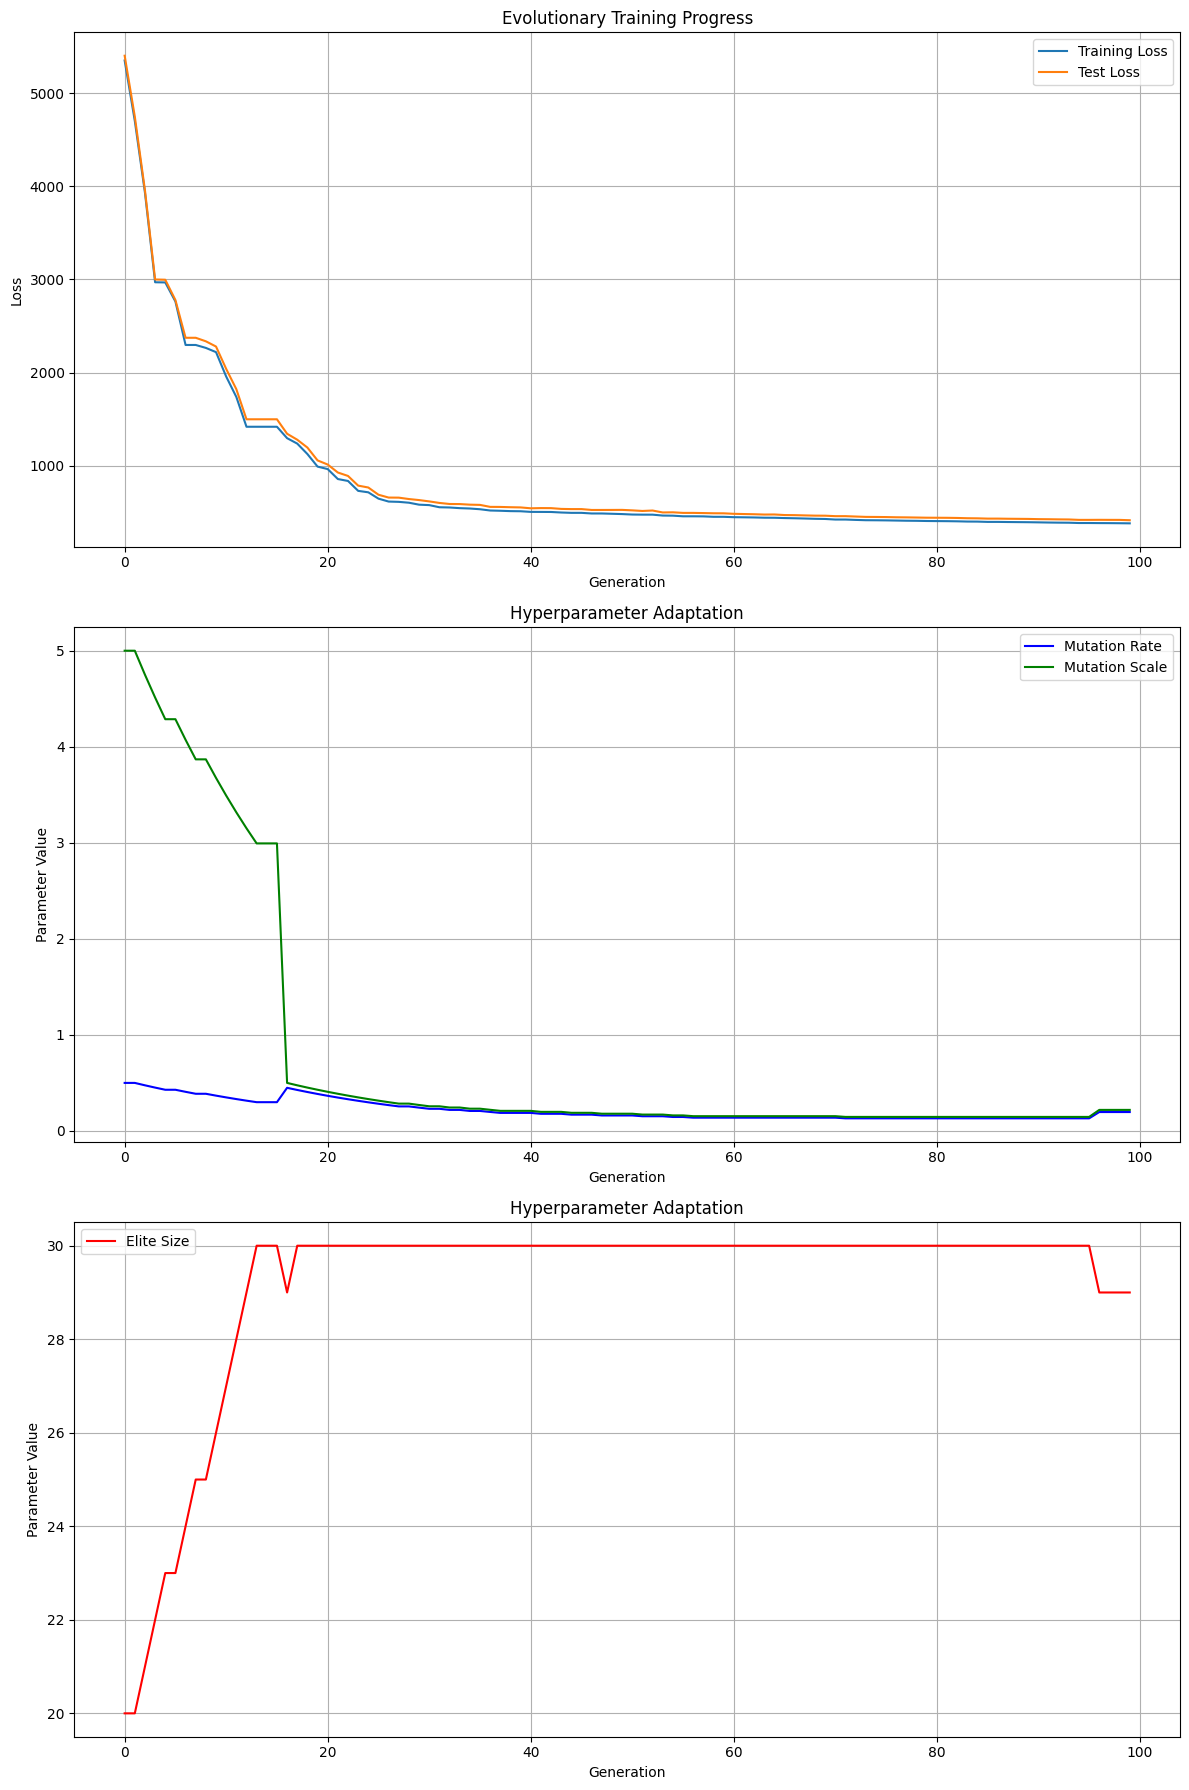

In [9]:
plot_training_progress(best_train_losses, best_test_losses, hyperparam_stories)

In [10]:
trained_network.evaluate_loss(X_test, y_test)

np.float64(413.67124154341985)

# auto-mpg

In [11]:
filepath = '../auto+mpg/auto-mpg.data'

# Column names
columns = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

# Read and parse each line
data = []
with open(filepath, 'r') as f:
    for line in f:
        # Split into 8 fields + quoted name (tab-separated before name)
        parts = line.strip().split(None, 8)
        if len(parts) == 9:
            parts[8] = parts[8].strip('"')  # remove quotes
            data.append(parts)

# Convert to DataFrame
df = pd.DataFrame(data, columns=columns)
for col in columns[:-1]:  # skip 'car_name'
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna()
df = df.drop(columns=["car_name"])
df = pd.get_dummies(df, columns=["origin"])
for i in range(3):
    column_name = f"origin_{i+1}"
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
data = df.values

X = data[:,0]
y = data[:,0:]

train_proportion = 0.8

X_train = X[:int(len(X)*train_proportion)]
y_train = y[:int(len(X)*train_proportion)]
X_test = X[int(len(X)*train_proportion):]
y_test = y[int(len(X)*train_proportion):]





In [13]:
network = SimpleMLP([10,10,10,1], "MSE", "tanh", True)
trained_network, best_train_losses, best_test_losses, hyperparam_stories = train_mlp_evolutionary(network,
                                                                                                  X_train,
                                                                                                  y_train,
                                                                                                  X_test,
                                                                                                  y_test,
                                                                                                  500,
                                                                                                  1000,
                                                                                                  10,
                                                                                                  20,
                                                                                                  0.5,
                                                                                                  5,
                                                                                                  0.7,
                                                                                                  True,
                                                                                                  10,
                                                                                                  True,
                                                                                                  3,
                                                                                                  0.01)

MSE
Generation 0: Best train loss = 10476780.545997, Best test loss = 6379522.238915 | mutation_rate=0.5000, mutation_scale=5.0000, elite_size=20

Generation 10: Best train loss = 9235158.371701, Best test loss = 5401726.755784 | mutation_rate=0.3675, mutation_scale=3.6755, elite_size=26

Generation 20: Best train loss = 8195383.114318, Best test loss = 4621265.045061 | mutation_rate=0.2702, mutation_scale=2.7018, elite_size=32

Generation 30: Best train loss = 7489829.746315, Best test loss = 4093470.407248 | mutation_rate=0.2201, mutation_scale=2.2006, elite_size=36

Generation 40: Best train loss = 7018881.156477, Best test loss = 3734277.988136 | mutation_rate=0.2201, mutation_scale=2.2006, elite_size=36

Generation 50: Best train loss = 6492354.124165, Best test loss = 3348817.829866 | mutation_rate=0.1887, mutation_scale=1.8868, elite_size=39

Generation 60: Best train loss = 6098433.197643, Best test loss = 3059760.911633 | mutation_rate=0.1792, mutation_scale=1.7924, elite_size

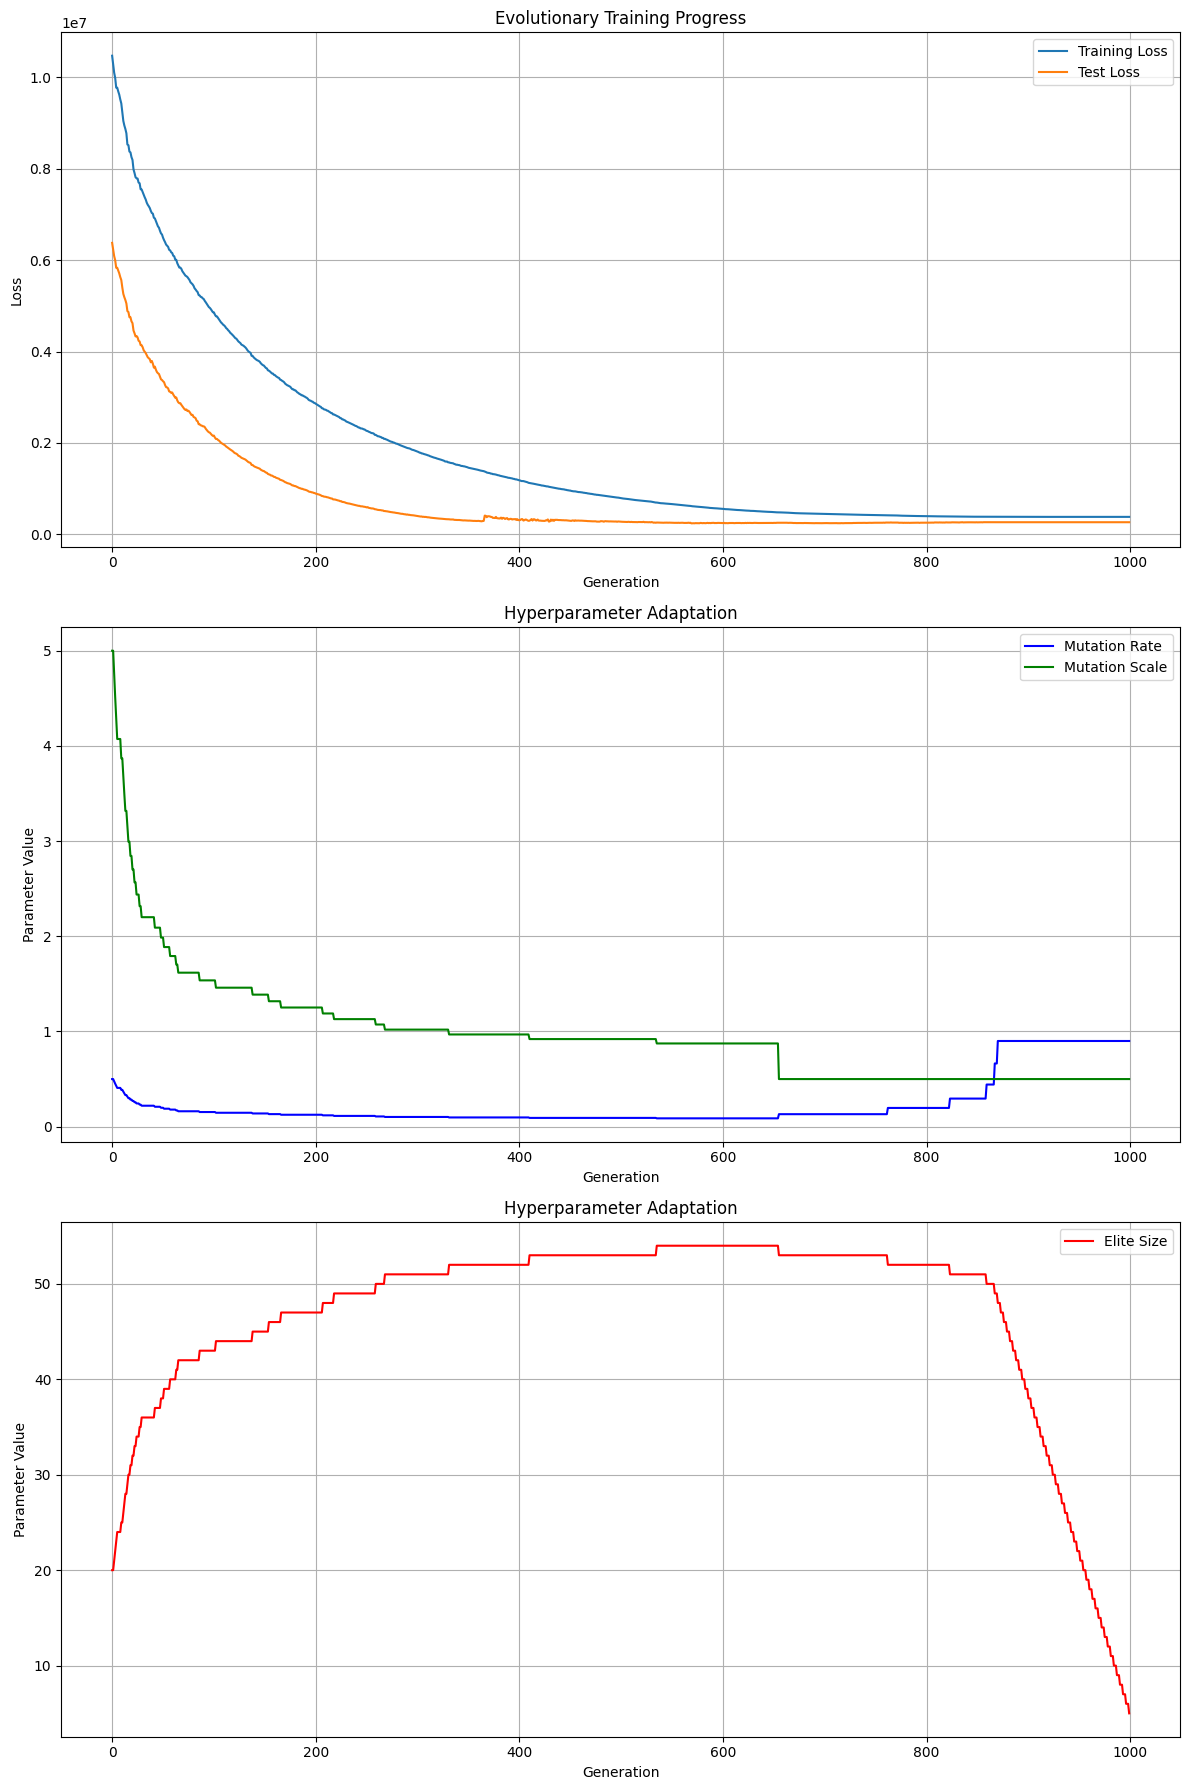

In [14]:
plot_training_progress(best_train_losses, best_test_losses, hyperparam_stories)

In [15]:
trained_network.evaluate_loss(X_test, y_test)

262611.5115343937

# iris

In [2]:
df = pd.read_csv('../iris/iris.data')
df = df.dropna()
df = pd.get_dummies(df, columns=['Iris-setosa'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
data = df.values

X = data[:,:4]
y = data[:,4:]

train_proportion = 0.8
X_train = X[:int(len(X)*train_proportion)].astype(np.float32)
y_train = y[:int(len(X)*train_proportion)].astype(np.float32)
X_test = X[int(len(X)*train_proportion):].astype(np.float32)
y_test = y[int(len(X)*train_proportion):].astype(np.float32)

In [3]:
network = SimpleMLP([4,10,10,3], "CE", "tanh", True)
trained_network, best_train_losses, best_test_losses, hyperparam_stories = train_mlp_evolutionary(network,
                                                                                                  X_train,
                                                                                                  y_train,
                                                                                                  X_test,
                                                                                                  y_test,
                                                                                                  200,
                                                                                                  50,
                                                                                                  10,
                                                                                                  20,
                                                                                                  0.5,
                                                                                                  0.5,
                                                                                                  0.7,
                                                                                                  True,
                                                                                                  1,
                                                                                                  True,
                                                                                                  3,
                                                                                                  0.01)

CE
Generation 0: Best train loss = 1.078115, Best test loss = 1.085585 | mutation_rate=0.5000, mutation_scale=0.5000, elite_size=20
 | Best train accuracy = 0.361345
 | Best test accuracy = 0.233333
Generation 1: Best train loss = 0.828168, Best test loss = 0.811942 | mutation_rate=0.4750, mutation_scale=0.4750, elite_size=21
 | Best train accuracy = 0.663866
 | Best test accuracy = 0.666667
Generation 2: Best train loss = 0.828168, Best test loss = 0.811942 | mutation_rate=0.4750, mutation_scale=0.4750, elite_size=21
 | Best train accuracy = 0.663866
 | Best test accuracy = 0.666667
Generation 3: Best train loss = 0.554468, Best test loss = 0.651345 | mutation_rate=0.4512, mutation_scale=0.4512, elite_size=22
 | Best train accuracy = 0.689076
 | Best test accuracy = 0.566667
Generation 4: Best train loss = 0.554468, Best test loss = 0.651345 | mutation_rate=0.4512, mutation_scale=0.4512, elite_size=22
 | Best train accuracy = 0.689076
 | Best test accuracy = 0.566667
Generation 5: Bes

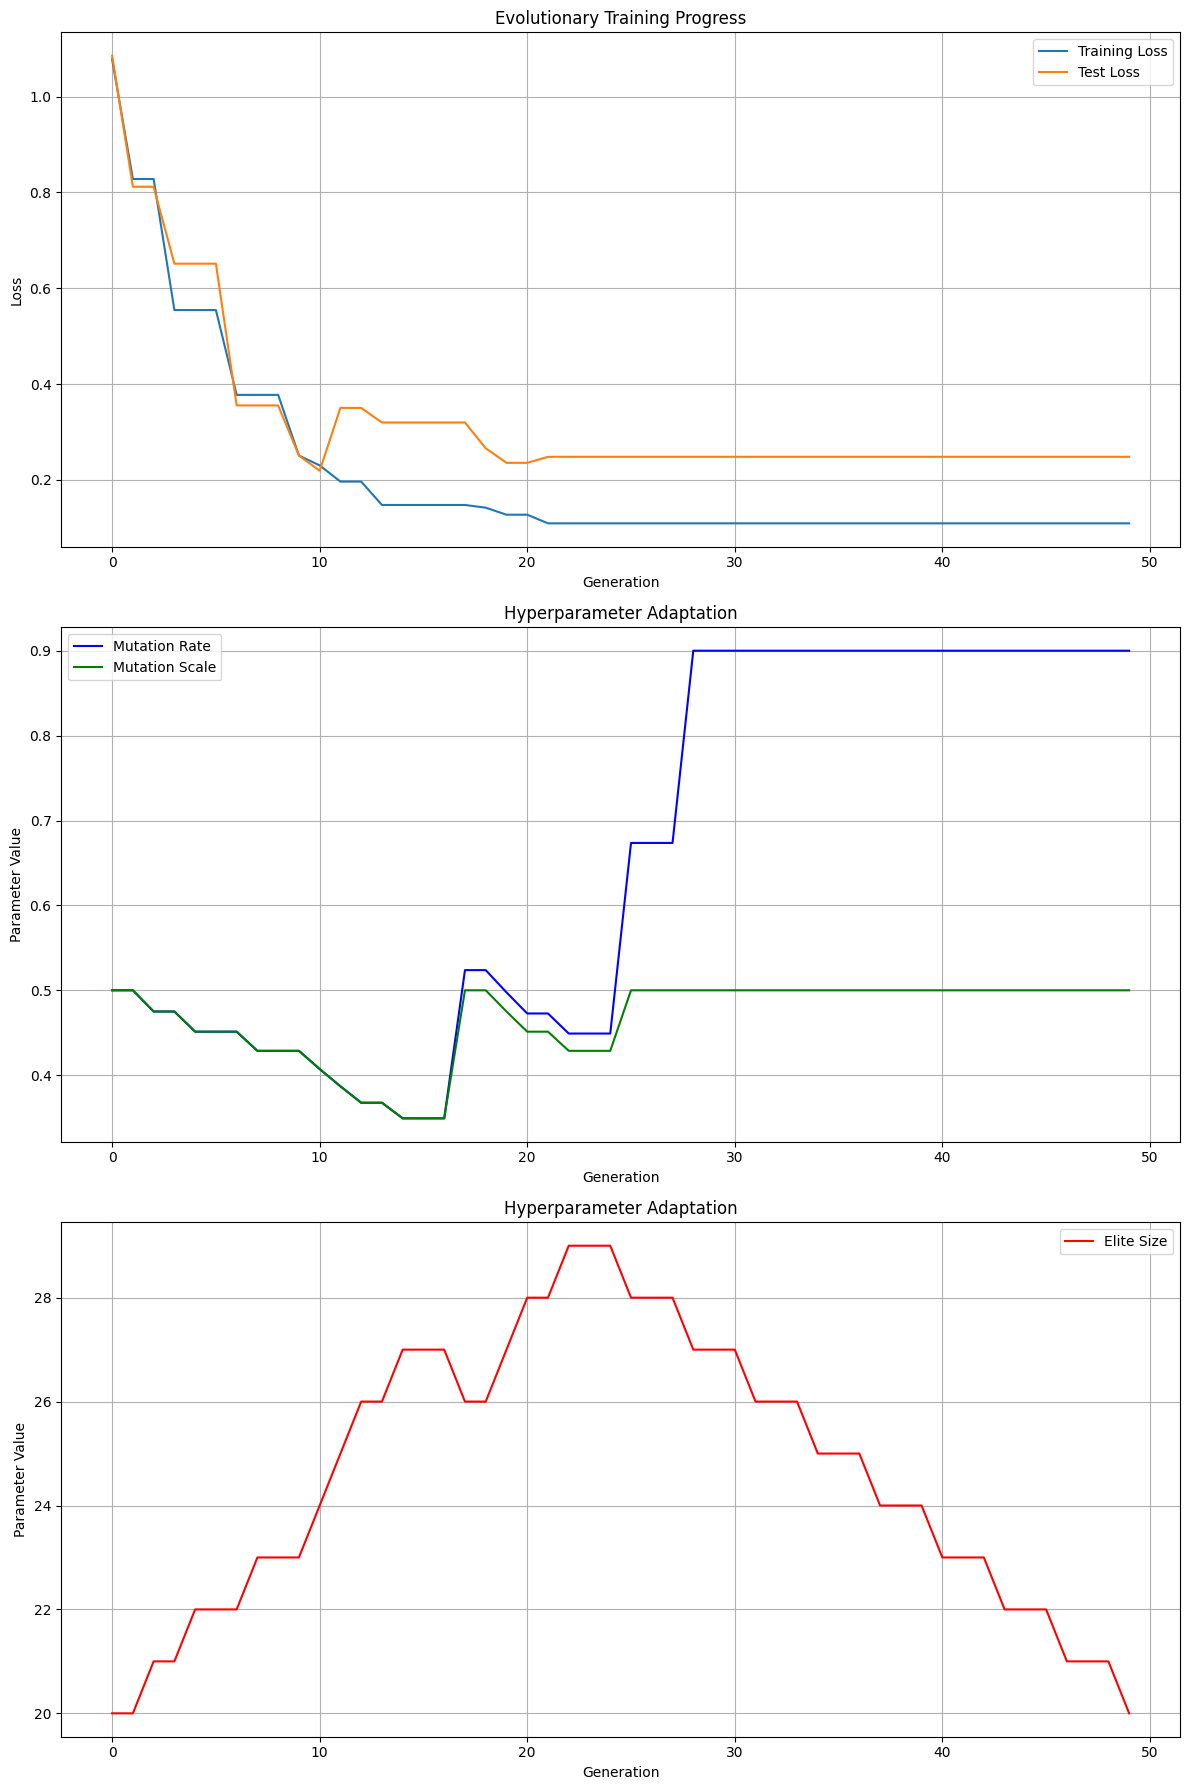

In [4]:
plot_training_progress(best_train_losses, best_test_losses, hyperparam_stories)

In [5]:
trained_network.evaluate_accuracy(X_test, y_test)

np.float64(0.9)